In [1]:
from math import inf
from typing import Dict, List, Set, Tuple
import random

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

In [2]:
%matplotlib inline

# Lecture 1: Bigrams

In [3]:
def read_data(data_path: str) -> List[str]:
    words = []
    with open(data_path, "r") as fh:
        for line in fh:
            words.append(line.strip())
    return words

In [4]:
words = read_data("names.txt")
print("Top ten words: ", words[:10])
print("Total words: ", len(words))
min_word_len = min([len(word) for word in words])
max_word_len = max([len(word) for word in words])
print("Min word length: ", min_word_len)
print("Max word length: ", max_word_len)

Top ten words:  ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
Total words:  32033
Min word length:  2
Max word length:  15


In [5]:
SEED = 2147483647
GENERATOR = torch.Generator().manual_seed(SEED)

In [6]:
SPECIAL = "."
letters = sorted(list(set("".join(words))))
alphabet = [SPECIAL] + letters
LTOI = {l: i for i, l in enumerate(alphabet)}
ITOL = {i: l for i, l in enumerate(alphabet)}

In [7]:
# character level model - what char is likely to follow a char
def bigram_dict(words: List[str]) -> Dict[Tuple[str, str], int]:
    freq = {}
    for word in words:
        letters = [SPECIAL] + list(word) + [SPECIAL]
        for bg in zip(letters, letters[1:]):
            if bg in freq:
                freq[bg] += 1
            else:
                freq[bg] = 1
    return freq

In [8]:
words = read_data("names.txt")
model = bigram_dict(words)
least_freq_bg = sorted(model.items(), key=lambda x: x[1])[0]
print("Least frequent bigram: ", least_freq_bg)
most_freq_bg = sorted(model.items(), reverse=True, key=lambda x: x[1])[0]
print("Most frequent bigram: ", most_freq_bg)


Least frequent bigram:  (('q', 'r'), 1)
Most frequent bigram:  (('n', '.'), 6763)


In [9]:
def train_bigram_tensor(words: List[str], dim: int) -> torch.Tensor:
    model = torch.zeros((dim, dim), dtype=torch.int32)
    for word in words:
        letters = [SPECIAL] + list(word) + [SPECIAL]
        for l1, l2 in zip(letters, letters[1:]):
            idx1, idx2 = LTOI[l1], LTOI[l2]
            model[idx1, idx2] += 1

    #  normalize tensor
    prob_dist = (model + 1).float()
    prob_dist /= prob_dist.sum(1, keepdim=True)
    return prob_dist

In [10]:
def apply_biagram_tensor(model: torch.Tensor, max_iterations: int = 100, generator=GENERATOR) -> str:
    result = []

    idx = 0
    for _ in range(max_iterations):
        prob = model[idx]
        idx = torch.multinomial(prob, num_samples=1, replacement=True, generator=generator).item()
        result.append(ITOL[idx])
        if idx == 0:
            break
    return "".join(result)

In [11]:
def plot_biagram_tensor_model(model: torch.Tensor, dim: int):
    plt.figure(figsize=(16, 16))
    plt.imshow(model, cmap="Reds")  # heatmaps feel like they should be red
    plt.axis("off")
    for i in range(dim):
        for j in range(dim):
            li = ITOL[i]
            lj = ITOL[j]
            if li is None or lj is None:
                continue
            plt.text(j, i, str(round(model[i, j].item(), 3)), ha="center", va="top")
            plt.text(j, i, li + lj, ha="center", va="bottom")
    return

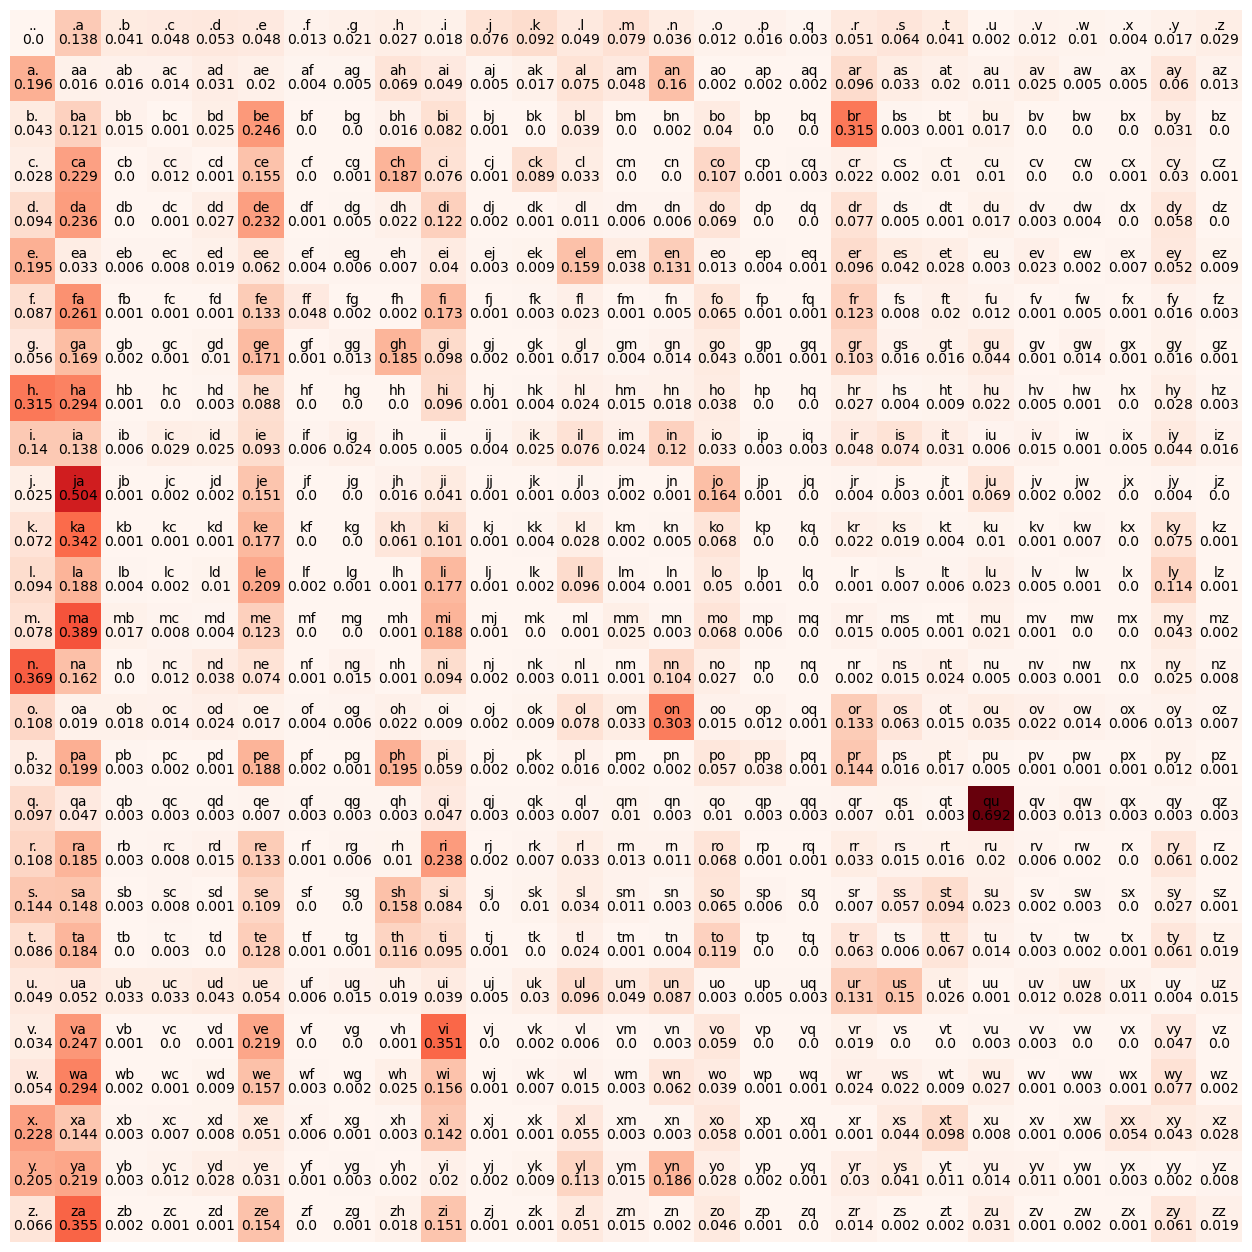

In [12]:
model = train_bigram_tensor(words, len(alphabet))
plot_biagram_tensor_model(model, len(alphabet))

In [13]:
for _ in range(10):
    result = apply_biagram_tensor(model)
    print(result)

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [14]:
def evaluate_biagram_tensor_model(model: torch.Tensor):
    log_likelihood = 0.0
    n = 0
    for word in words:
        letters = [SPECIAL] + list(word) + [SPECIAL]
        for l1, l2 in zip(letters, letters[1:]):
            idx1, idx2 = LTOI[l1], LTOI[l2]
            log_likelihood += torch.log(model[idx1, idx2])
            n += 1
    return (-1 * log_likelihood) / n

In [15]:
log_likelihood = evaluate_biagram_tensor_model(model)
print("Log Likelihood: ", round(log_likelihood.item(), 3))

Log Likelihood:  2.454


In [16]:
def create_bigram_training_set(words, dim: int):
    features, labels = [], []
    for word in words:
        letters = [SPECIAL] + list(word) + [SPECIAL]
        for l1, l2 in zip(letters, letters[1:]):
            idx1, idx2 = LTOI[l1], LTOI[l2]
            features.append(idx1)
            labels.append(idx2)

    features_t = torch.tensor(features)
    features_t = F.one_hot(features_t, num_classes=dim).float()

    labels_t = torch.tensor(labels)
    return features_t, labels_t

In [17]:
features_t, labels_t = create_bigram_training_set(words, len(alphabet))
print(features_t.shape)
print(labels_t.shape)

torch.Size([228146, 27])
torch.Size([228146])


In [18]:
def train_bigram_nn(
    features_t: torch.Tensor,
    labels_t: torch.Tensor,
    n_inputs: int,
    n_outputs: int,
    alpha: float = 0.1,
    epsilon=10**-5,
    max_iterations: int = 100,
    verbose: bool = True,
    print_freq: int = 1,
    generator=GENERATOR,
) -> Tuple[torch.Tensor, torch.Tensor]:
    indices = torch.arange(len(labels_t))
    weights = torch.randn((n_inputs, n_outputs), requires_grad=True, generator=generator)
    probabilities = torch.zeros((n_inputs, n_outputs))
    prev_loss = inf
    for iteration in range(max_iterations):
        # softmax
        z = (features_t @ weights).exp()
        probabilities = z / z.sum(1, keepdim=True)

        # loss
        loss = -probabilities[indices, labels_t].log().mean()

        # backward pass
        weights.grad = None
        loss.backward()

        if loss > prev_loss:
            alpha /= 10

        if verbose and (iteration % print_freq == 0):
            print(f"{iteration}\t{loss:.6f}")

        weights.data += alpha * weights.grad  # type: ignore
        if abs(loss - prev_loss) < epsilon:
            return (weights, probabilities)
        prev_loss = loss

    return (weights, probabilities)

In [19]:
weights, probabilities = train_bigram_nn(features_t, labels_t, len(alphabet), len(alphabet))

0	3.750659
1	3.751494
2	3.751578
3	3.751586


In [20]:
def evaluate_bigram_nn(probabilities: torch.Tensor, labels_t: torch.Tensor):
    n = 5
    log_likelihoods = torch.zeros(n)
    for i in range(n):
        y = labels_t[i]
        p = probabilities[i, y]
        logp = torch.log(p)
        log_likelihoods[i] = -logp
    return log_likelihoods.mean().item()

In [21]:
mean_log_likelihood = evaluate_bigram_nn(probabilities, labels_t)
print("Mean Log Likelihood: ", round(mean_log_likelihood, 3))

Mean Log Likelihood:  4.161


In [22]:
def apply_bigram_nn(weights: torch.Tensor, dim: int, max_iterations: int = 100, generator=GENERATOR):
    result = []
    idx = 0
    for _ in range(max_iterations):
        x = F.one_hot(torch.tensor([idx]), num_classes=dim).float()
        z = x @ model
        probabilities = z.exp()
        prob = probabilities / probabilities.sum(1, keepdim=True)
        idx = torch.multinomial(prob, num_samples=1, replacement=True, generator=generator).item()
        result.append(ITOL[idx])
        if idx == 0:
            break
    return "".join(result)

In [23]:
for _ in range(5):
    result = apply_bigram_nn(weights, len(alphabet))
    print(result)

ybiiictjfsihququzd.
egehkewsjsb.
gjolcvltnyqbensbylyzuwpuqwgzmuhe.
ggqqjqup.
duiijepkeqibbzttgbtnkzhq.


# Lecture 2: MLP

In [24]:
CONTEXT_SIZE = 3
EMBED_SIZE = 2

In [25]:
def generate_dataset(words: List[str], context_size: int) -> Tuple[torch.Tensor, torch.Tensor]:
    features, labels = [], []
    for word in words:
        context = [0] * context_size
        for char in word + ".":
            idx = LTOI[char]
            features.append(context)
            labels.append(idx)
            context = context[1:] + [idx]  # window

    features_t = torch.tensor(features)
    labels_t = torch.tensor(labels)
    return features_t, labels_t

In [26]:
features_t, labels_t = generate_dataset(words, CONTEXT_SIZE)

d1 = int(0.8 * len(words))
d2 = int(0.9 * len(words))
train_features, train_labels = generate_dataset(words[:d1], CONTEXT_SIZE)
print("Training set: ", train_features.shape)
dev_features, dev_labels = generate_dataset(words[d1:d2], CONTEXT_SIZE)
print("Dev set: ", dev_features.shape)
test_features, test_labels = generate_dataset(words[d2:], CONTEXT_SIZE)
print("Test set: ", test_features.shape)

Training set:  torch.Size([182778, 3])
Dev set:  torch.Size([22633, 3])
Test set:  torch.Size([22735, 3])


In [27]:
def pretty_print_dataset(features_t: torch.Tensor, labels_t: torch.Tensor, head: int = 20):
    for x, y in zip(features_t[:head], labels_t[:head]):
        print("".join(ITOL[ix.item()] for ix in x), "-->", ITOL[y.item()])
    return

In [28]:
pretty_print_dataset(train_features, train_labels)

... --> e
..e --> m
.em --> m
emm --> a
mma --> .
... --> o
..o --> l
.ol --> i
oli --> v
liv --> i
ivi --> a
via --> .
... --> a
..a --> v
.av --> a
ava --> .
... --> i
..i --> s
.is --> a
isa --> b


In [29]:
def create_embedding(features_t: torch.Tensor, n_inputs: int, lower_dim: int, generator=GENERATOR) -> torch.Tensor:
    print(n_inputs)
    embedding = torch.randn((n_inputs, lower_dim), requires_grad=True, generator=generator)
    print("Embedding: ", embedding.shape)
    return embedding

In [30]:
embedding = create_embedding(features_t, len(alphabet), EMBED_SIZE)
print("Embedding: ", embedding.shape)

27
Embedding:  torch.Size([27, 2])
Embedding:  torch.Size([27, 2])


In [31]:
def init_mlp(n_inputs, n_hidden, n_outputs, generator):
    weights1 = torch.randn((n_inputs, n_hidden), generator=generator, requires_grad=True)
    bias1 = torch.randn(n_hidden, generator=generator, requires_grad=True)

    weights2 = torch.randn((n_hidden, n_outputs), generator=generator, requires_grad=True)
    bias2 = torch.randn(n_outputs, generator=generator, requires_grad=True)
    return weights1, bias1, weights2, bias2

In [32]:
def train_mlp(
    features_t: torch.Tensor,
    embedding: torch.Tensor,
    labels_t: torch.Tensor,
    n_inputs: int,
    weights1: torch.Tensor,
    bias1: torch.Tensor,
    weights2: torch.Tensor,
    bias2: torch.Tensor,
    alpha: float = 0.1,
    batch_size: int = 32,
):
    tensors = [embedding, weights1, bias1, weights2, bias2]

    # minibatch
    idx = torch.randint(0, features_t.shape[0], (batch_size,))
    batch = embedding[features_t[idx]]

    # softmax
    z1 = torch.tanh(batch.view((-1, n_inputs)) @ weights1 + bias1)
    z2 = z1 @ weights2 + bias2
    loss = F.cross_entropy(z2, labels_t[idx])

    # backward pass
    for t in tensors:
        t.grad = None

    loss.backward()
    for t in tensors:
        t.data += -1 * alpha * t.grad
    return loss

In [33]:
def learn_mlp(
    embedding: torch.Tensor,
    features_t: torch.Tensor,
    labels_t: torch.Tensor,
    n_inputs: int,
    n_hidden: int,
    n_outputs: int,
    alpha: float = 0.1,
    epsilon=10**-5,
    max_iterations: int = 10000,
    verbose: bool = True,
    print_freq: int = 1000,
    generator=GENERATOR,
):
    weights1, bias1, weights2, bias2 = init_mlp(n_inputs, n_hidden, n_outputs, generator)
    prev_loss = inf
    losses = []
    for iteration in range(max_iterations):
        alpha =  0.1 if iteration < 100000 else 0.01

        loss = train_mlp(features_t, embedding, labels_t, n_inputs, weights1, bias1, weights2, bias2, alpha)
        losses.append(loss.log().item())
        
        if verbose and (iteration % print_freq == 0):
            print(f"{iteration}\t{loss:.6f}")

        if abs(loss - prev_loss) < epsilon:
            return weights1, bias1, weights2, bias2, losses
        prev_loss = loss

    return weights1, bias1, weights2, bias2, losses

In [34]:
n_input = CONTEXT_SIZE * EMBED_SIZE
n_hidden = 100
weights1, bias1, weights2, bias2, losses = learn_mlp(embedding, train_features, train_labels, CONTEXT_SIZE * EMBED_SIZE, n_hidden, len(alphabet))

0	15.265258
1000	2.485726
2000	2.453174
3000	2.420317
4000	2.483339
5000	2.442901
6000	2.530198
7000	2.299088
8000	2.332412
9000	2.518507


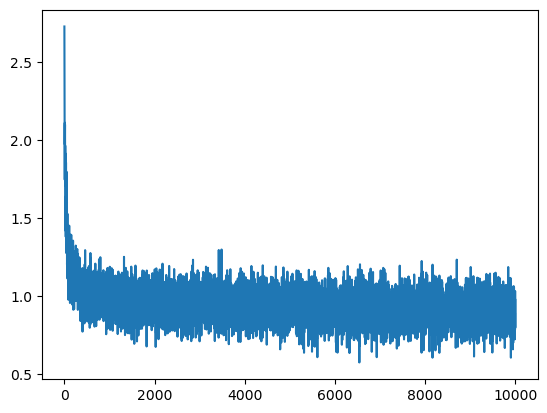

In [35]:
plt.plot(range(len(losses)), losses)

In [36]:
def evaluate_mlp(train_features, dim, labels_t, embedding: torch.Tensor, weights1, bias1, weights2, bias2):
    batch = embedding[train_features]
    z1 = torch.tanh(batch.view(-1, dim) @ weights1 + bias1)
    z2 = z1 @ weights2 + bias2
    loss = F.cross_entropy(z2, labels_t)
    return loss

In [37]:
train_loss = evaluate_mlp(train_features, CONTEXT_SIZE * EMBED_SIZE, train_labels, embedding, weights1, bias1, weights2, bias2)
print("Training Loss: ", train_loss)

dev_loss = evaluate_mlp(dev_features, CONTEXT_SIZE * EMBED_SIZE, dev_labels, embedding, weights1, bias1, weights2, bias2)
print("Validation Loss: ", dev_loss)

test_loss = evaluate_mlp(test_features, CONTEXT_SIZE * EMBED_SIZE, test_labels, embedding, weights1, bias1, weights2, bias2)
print("Test Loss: ", test_loss)

Training Loss:  tensor(2.4857, grad_fn=<NllLossBackward0>)
Validation Loss:  tensor(2.6638, grad_fn=<NllLossBackward0>)
Test Loss:  tensor(2.6617, grad_fn=<NllLossBackward0>)


In [38]:
def apply_model(embedding: torch.Tensor, weights1, bias1, weights2, bias2, max_iterations: int = 100, generator=GENERATOR):
    result = []
    context = [0] * CONTEXT_SIZE
    for iteration in range(max_iterations):
        batch = embedding[torch.tensor([context])]
        z1 = torch.tanh(batch.view(1, -1) @ weights1 + bias1)
        z2 = z1 @ weights2 + bias2
        probabilities = torch.softmax(z2, dim=1)
        idx = torch.multinomial(probabilities, num_samples=1, generator=generator).item()
        context = context[1:] + [idx]
        result.append(ITOL[idx])
        if idx == 0:
            break
    return "".join(result)

In [39]:
for _ in range(5):
    result = apply_model(embedding, weights1, bias1, weights2, bias2)
    print(result)

ref.
roes.
telio.
pictliv.
zit.


# Lecture 3: batchnorm


In [40]:
def bn():
    return

# Lecture 4: backprop


In [41]:
def backprop():
    return

# Lecture 5: cnn

In [ ]:
CONTEXT_SIZE = 8

In [ ]:
features_t, labels_t = generate_dataset(words, CONTEXT_SIZE)

d1 = int(0.8 * len(words))
d2 = int(0.9 * len(words))
train_features, train_labels = generate_dataset(words[:d1], CONTEXT_SIZE)
print("Training set: ", train_features.shape)
dev_features, dev_labels = generate_dataset(words[d1:d2], CONTEXT_SIZE)
print("Dev set: ", dev_features.shape)
test_features, test_labels = generate_dataset(words[d2:], CONTEXT_SIZE)
print("Test set: ", test_features.shape)

In [45]:
def cnn():
    return